Model training 
- Import data and required packages 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/raw.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group C,associate's degree,standard,none,91,86,84
1,female,group B,some college,free/reduced,completed,53,66,73
2,male,group D,bachelor's degree,standard,none,80,73,72
3,male,group C,some college,free/reduced,none,74,77,73
4,male,group E,some college,standard,completed,84,83,78


In [4]:
# Preparing X and Y variables
X = df.drop(columns=['math_score'])

In [5]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group C,associate's degree,standard,none,86,84
1,female,group B,some college,free/reduced,completed,66,73
2,male,group D,bachelor's degree,standard,none,73,72
3,male,group C,some college,free/reduced,none,77,73
4,male,group E,some college,standard,completed,83,78


In [11]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:   <StringArray>
['group C', 'group B', 'group D', 'group E', 'group A']
Length: 5, dtype: str
Categories in'parental level of education' variable: <StringArray>
['associate's degree',       'some college',  'bachelor's degree',
   'some high school',        'high school',    'master's degree']
Length: 6, dtype: str
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:      <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [6]:
y = df['math_score']

In [7]:
y

0      91
1      53
2      80
3      74
4      84
       ..
194    60
195    52
196    62
197    74
198    65
Name: math_score, Length: 199, dtype: int64

In [8]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [9]:
X = preprocessor.fit_transform(X)

In [10]:
X.shape

(199, 19)

In [11]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((159, 19), (40, 19))

In [12]:
# Create an Evaluate Function to give all metrics after model Training
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))


    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.1665
- Mean Absolute Error: 4.0497
- R2 Score: 0.9018
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 4.8749
- Mean Absolute Error: 4.0885
- R2 Score: 0.8250


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.3264
- Mean Absolute Error: 4.9541
- R2 Score: 0.8528
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.5598
- Mean Absolute Error: 4.4747
- R2 Score: 0.7723


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.1717
- Mean Absolute Error: 4.0411
- R2 Score: 0.9016
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 4.8491
- Mean Absolute Error: 4.0628
- R2 Score: 0.8268


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 6.4841
- Mean Absolute Error: 5.1233
- R2 Score: 0.8453
-----------------------

In [14]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.826798
0,Linear Regression,0.824954
7,CatBoosting Regressor,0.816513
5,Random Forest Regressor,0.788792
1,Lasso,0.772309
8,AdaBoost Regressor,0.739205
6,XGBRegressor,0.738631
3,K-Neighbors Regressor,0.703381
4,Decision Tree,0.636491


In [15]:
# Linear Regression
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 82.50


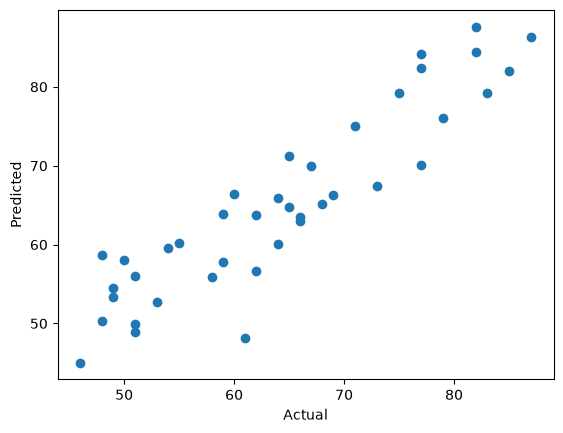

In [16]:
# Plot y_pred and y_test
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

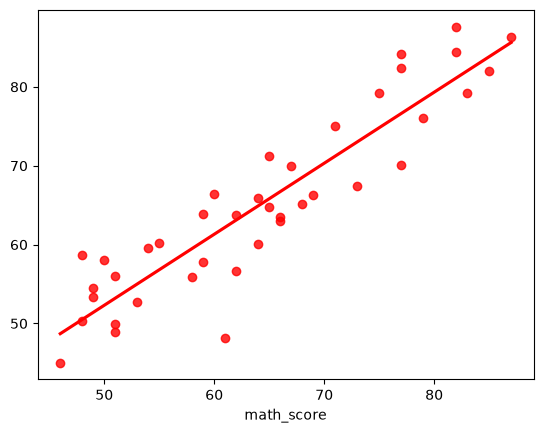

In [ ]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [18]:
#  Difference between actual and predicted values
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
82,83,79.262456,3.737544
15,65,71.207455,-6.207455
111,71,74.986867,-3.986867
177,65,64.725145,0.274855
76,85,81.996524,3.003476
163,51,56.067131,-5.067131
68,58,55.952059,2.047941
67,59,57.741184,1.258816
120,50,58.046817,-8.046817
173,67,69.999795,-2.999795
